# 03 · The Distribution Zoo

**Session 3 · Sat Sep 19 · 1.5 hours (stats half)**

### The idea behind this notebook

A *distribution* is just the answer to "which values happen, and how often?"

Rather than read definitions, you are going to **generate** each one. When you build a distribution
from a rule and then look at it, the shape stops being a definition to memorise and becomes something
you recognise, the way you recognise a face. That is the whole point of this session.

Each section follows the same pattern: the rule that generates it, what it looks like, and where you
have already met it at work.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
DATA = Path.cwd() / "data" if (Path.cwd() / "data").exists() else Path.cwd().parent / "data"
rng = np.random.default_rng(42)   # same seed => same numbers every time you run this

## 1 · Uniform — "every value equally likely"

The simplest possible rule. A fair die, a random ID, a lottery number.

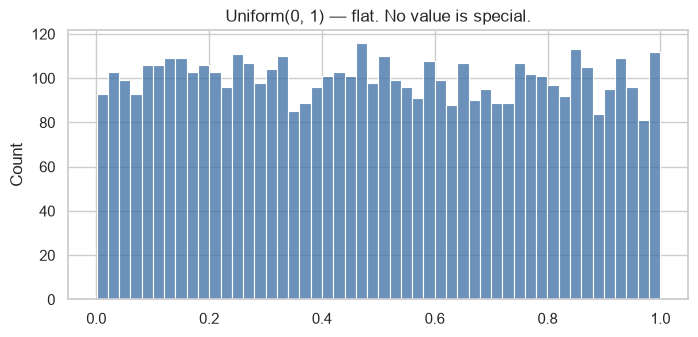

mean 0.496  (theory: 0.5)   std 0.288  (theory: 0.289)


In [2]:
u = rng.uniform(0, 1, 5000)

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.histplot(u, bins=50, ax=ax, color="#3b6ea5")
ax.set_title("Uniform(0, 1) — flat. No value is special.")
plt.show()

print(f"mean {u.mean():.3f}  (theory: 0.5)   std {u.std():.3f}  (theory: {1/np.sqrt(12):.3f})")

## 2 · Normal — "many small independent nudges"

The bell curve. Notation: `X ~ N(µ, σ²)`, read aloud as *"X is distributed normal with mean µ and
variance σ²."* The `~` means "is drawn from."

`µ` moves the curve left and right. `σ` makes it wide or narrow. That is the entire parameterisation.

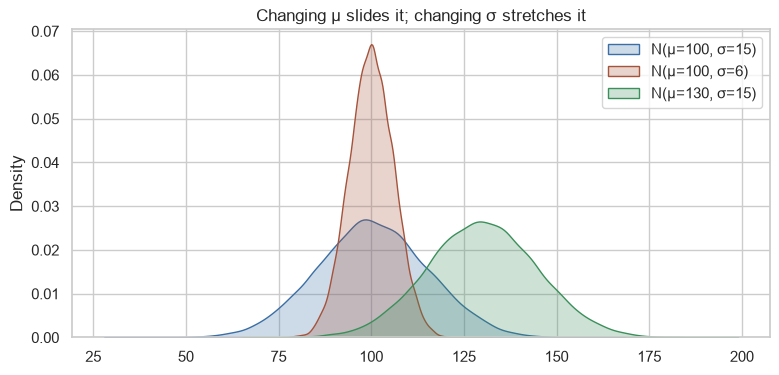

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
for mu, sd, c in [(100, 15, "#3b6ea5"), (100, 6, "#a5533b"), (130, 15, "#3b8f5a")]:
    sns.kdeplot(rng.normal(mu, sd, 20000), ax=ax, label=f"N(µ={mu}, σ={sd})",
                fill=True, alpha=.25, color=c)
ax.set_title("Changing µ slides it; changing σ stretches it")
ax.legend(); plt.show()

### The 68 / 95 / 99.7 rule

For any normal distribution, regardless of `µ` and `σ`:

- ~68% of values fall within **1σ** of the mean
- ~95% within **2σ**
- ~99.7% within **3σ**

This is worth memorising — it turns `σ` from an abstraction into a ruler, and it is where the phrase
"a three-sigma event" comes from.

In [4]:
z = rng.normal(0, 1, 200_000)
for k in (1, 2, 3):
    print(f"within {k}σ: {np.mean(np.abs(z) < k):6.2%}")

within 1σ: 68.35%
within 2σ: 95.41%
within 3σ: 99.72%


## 3 · Log-normal — "many small *multiplicative* nudges"

If you take a normal distribution and exponentiate it, you get log-normal. It is right-skewed and it
is what money looks like.

**Why money is log-normal rather than normal:** incomes and balances grow by *percentages*, not by
fixed amounts. A 3% raise on a large salary is more dollars than 3% on a small one. Multiplicative
processes produce log-normal distributions the same way additive processes produce normal ones.

That single sentence explains the mean/median gap you found in notebook 01.

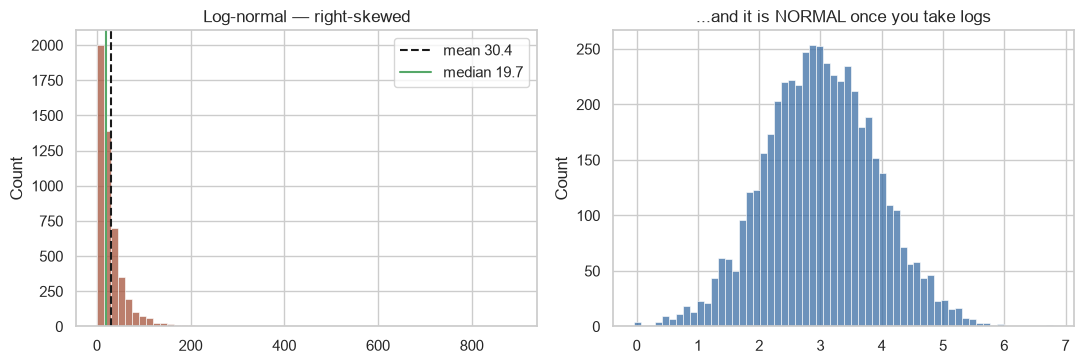

In [5]:
ln = rng.lognormal(mean=3, sigma=0.9, size=5000)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
sns.histplot(ln, bins=60, ax=axes[0], color="#a5533b")
axes[0].set_title("Log-normal — right-skewed")
axes[0].axvline(ln.mean(), color="k", ls="--", label=f"mean {ln.mean():.1f}")
axes[0].axvline(np.median(ln), color="g", ls="-", label=f"median {np.median(ln):.1f}")
axes[0].legend()

sns.histplot(np.log(ln), bins=60, ax=axes[1], color="#3b6ea5")
axes[1].set_title("...and it is NORMAL once you take logs")
plt.tight_layout(); plt.show()

The right-hand plot is why analysts log-transform money before modelling it. It is not a trick to
make numbers look nicer — it converts a multiplicative process into an additive one, which is the
form every standard technique assumes.

## 4 · Binomial — "how many successes in n tries?"

Counting outcomes of repeated yes/no trials. `n` trials, probability `p` each. Loan defaults in a
portfolio, click-throughs, fraud flags in a batch.

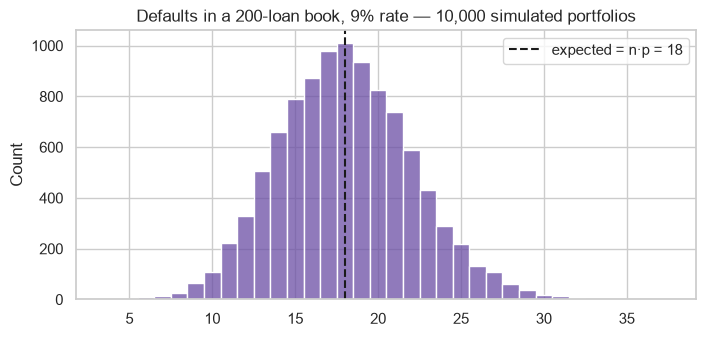

mean 18.03  (theory n·p = 18.0)
in 5% of portfolios you'd see 25+ defaults, purely by chance


In [6]:
defaults = rng.binomial(n=200, p=0.09, size=10000)   # 200 loans, 9% default rate each

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.histplot(defaults, bins=range(0, 45), ax=ax, color="#6b4ea5", discrete=True)
ax.set_title("Defaults in a 200-loan book, 9% rate — 10,000 simulated portfolios")
ax.axvline(200*0.09, color="k", ls="--", label="expected = n·p = 18")
ax.legend(); plt.show()

print(f"mean {defaults.mean():.2f}  (theory n·p = {200*0.09:.1f})")
print(f"in 5% of portfolios you'd see {np.percentile(defaults, 95):.0f}+ defaults, "
      f"purely by chance")

### The point of that last line

Expected defaults are 18. But roughly one book in twenty shows 25 or more **with no change whatever
in underlying credit quality** — just luck of the draw.

This is what "random variation" means in practice, and it is why a single quarter's uptick is not
evidence of deterioration. Distinguishing real signal from this kind of noise is precisely what
hypothesis testing (Session 10) is for.

## 5 · Poisson — "how many events in a window?"

Counts of things arriving over time when arrivals are independent: calls per hour, fraud attempts per
day, defects per batch. One parameter, `λ` (lambda), which is both the mean and the variance.

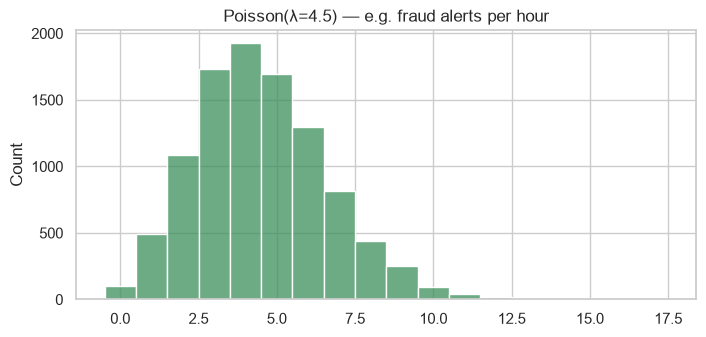

mean 4.50   variance 4.44   (both ≈ λ = 4.5)
P(zero events) = 0.010


In [7]:
calls = rng.poisson(lam=4.5, size=10000)

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.histplot(calls, discrete=True, ax=ax, color="#3b8f5a")
ax.set_title("Poisson(λ=4.5) — e.g. fraud alerts per hour")
plt.show()

print(f"mean {calls.mean():.2f}   variance {calls.var():.2f}   (both ≈ λ = 4.5)")
print(f"P(zero events) = {np.mean(calls == 0):.3f}")

## 6 · The comparison you should keep

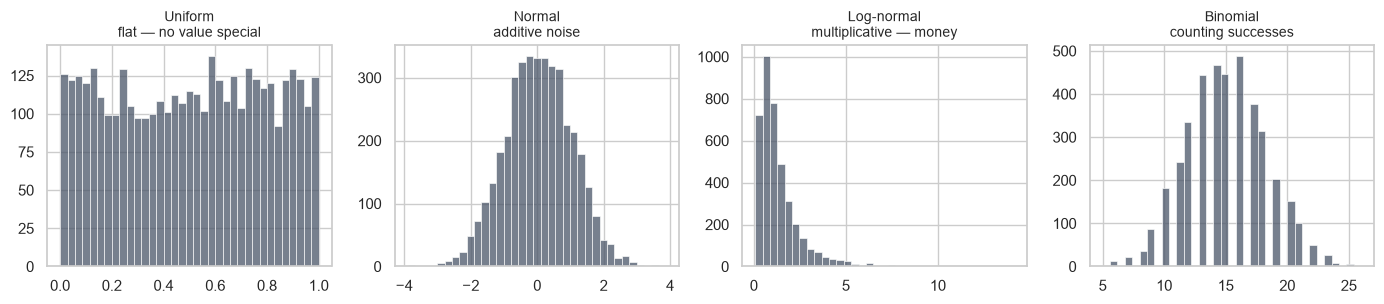

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
specs = [
    ("Uniform",    rng.uniform(0, 1, 4000),              "flat — no value special"),
    ("Normal",     rng.normal(0, 1, 4000),               "additive noise"),
    ("Log-normal", rng.lognormal(0, .8, 4000),           "multiplicative — money"),
    ("Binomial",   rng.binomial(50, .3, 4000),           "counting successes"),
]
for axis, (name, data, note) in zip(axes, specs):
    sns.histplot(data, bins=35, ax=axis, color="#4a5568")
    axis.set_title(f"{name}\n{note}", fontsize=10)
    axis.set_ylabel("")
plt.tight_layout(); plt.show()

## Your turn

**Exercise 1.** Generate 5,000 draws from a normal with mean 700 and standard deviation 60 (roughly a
credit-score distribution). What fraction fall below 620 — a common approval cutoff?

In [9]:
# your code here

In [ ]:
scores = rng.normal(700, 60, 5000)
below = np.mean(scores < 620)
print(f"{below:.2%} fall below 620")
print(f"that is {(620-700)/60:.2f} standard deviations below the mean")
# ~9%. Note this is the 68/95/99.7 rule in action: 620 is about 1.33σ below the mean.

**Exercise 2.** A 500-loan book with a 6% default rate. Simulate 10,000 such books. What is the
*worst* default count you would expect to see in the top 1% of outcomes?

In [11]:
# your code here

In [ ]:
books = rng.binomial(500, 0.06, 10000)
print(f"expected defaults: {500*0.06:.0f}")
print(f"99th percentile:   {np.percentile(books, 99):.0f}")
print(f"worst simulated:   {books.max()}")
# Expected 30, but 1 book in 100 sees ~43+. If you wrote a risk limit at 35 you would
# breach it roughly once every eight books through luck alone.

**Exercise 3.** Take the log-normal sample `ln` from section 3. Confirm by computation that `np.log(ln)`
is roughly symmetric while `ln` is not, using `pd.Series(...).skew()`.

In [13]:
# your code here

In [ ]:
print(f"skew of raw log-normal: {pd.Series(ln).skew():.2f}   (strongly right-skewed)")
print(f"skew after log:         {pd.Series(np.log(ln)).skew():.2f}   (≈ 0, symmetric)")

## What you did today

- Generated six distributions from their rules and learned them by sight, not by definition.
- The 68/95/99.7 rule, which makes `σ` a usable ruler.
- **Why money is log-normal** — multiplicative growth — and why logs are the standard fix.
- Saw that expected values come with real variation around them, which is the setup for inference.

**Next:** `04_randomness.ipynb`.